# Analisis & Visualisasi Proyek IHSG Forecasting (StockMixer V1)

Notebook ini dibuat khusus untuk keperluan presentasi PPT proyek Anda dengan fokus penuh pada **Model V1 (Baseline)**. Seluruh visualisasi, korelasi fitur, hipotesis preproses, dan visualisasi hasil model termuat di sini. Anda tinggal menjalankan sel-sel di bawah ini secara bertahap.

--- 
## 1. Latar Belakang & Tujuan

### **Latar Belakang**
*   **Tantangan Prediksi IHSG**: Pergerakan harga saham sangat dinamis dan dipengaruhi oleh tren historis (temporal) serta keterkaitan antar-saham di pasar (spasial).
*   **Kelemahan Model Lain**: Model deep learning konvensional (seperti LSTM) cenderung lambat dan sulit menangkap hubungan antar-saham. Model Graph (GNN) membutuhkan data relasi eksternal yang kompleks.
*   **Pendekatan StockMixer V1**: Menggunakan arsitektur berbasis MLP (*Multi-Layer Perceptron*) yang sangat ringan dan cepat. Dengan memproses 6 fitur utama melalui modul *Indicator Mixing*, *Temporal Mixing*, dan *Stock Mixing*, model ini secara efisien memprediksi return harian (1 hari ke depan) saham-saham di IHSG tanpa graf relasi rumit.

### **Tujuan**
1.  Melakukan forecasting pergerakan harga saham likuid di Bursa Efek Indonesia (IHSG) untuk 1 hari ke depan.
2.  Menganalisis korelasi 6 fitur input secara **keseluruhan (overall)** untuk seluruh saham bursa.
3.  Menyaring saham-saham terbaik (Bullish) berdasarkan skor keyakinan AI dengan batasan manajemen risiko (saham aktif & likuid).

--- 
## 2. Hipotesis & Use Case Proyek

### **1. Use Case Investor & Trader (Pengguna)**
*   **Masalah Pengguna**: Investor ritel sering kesulitan memilih saham terbaik secara objektif karena banyaknya jumlah emiten di IHSG. Ada juga risiko terjebak membeli saham tidak likuid (*saham gorengan*) atau saham mati (*saham gocap*).
*   **Usecase Aplikasi**: Sistem menyaring saham-saham likuid secara otomatis (Transaksi Harian > Rp 1 Miliar, Harga > Rp 51) dan menyajikan peringkat **Top 10 Rekomendasi Beli (Bullish)** untuk 1 hari ke depan berdasarkan skor keyakinan AI secara objektif.

### **2. Hipotesis & Pembuktian Algoritma**
*   **Hipotesis Relatif (Cross-Stock Ranking)**: Keuntungan investasi maksimal diperoleh dengan membeli saham yang kinerjanya *paling unggul* dibanding saham lain di hari yang sama. Oleh karena itu, model harus berfokus pada peringkat relatif antar-saham, bukan sekadar prediksi harga individu.
*   **Mekanisme Pembuktian StockMixer**:
    *   *Indicator Mixing*: Mengombinasikan data harga, volume, dan RSI untuk memetakan kekuatan pasar secara multi-dimensi.
    *   *Temporal Mixing*: Menangkap sinyal tren historis (momentum 16 hari bursa terakhir).
    *   *Stock Mixing*: Mempelajari keterkaitan pergerakan antar-saham di bursa secara bersamaan (*cross-sectional*).
*   **Metrik Pembuktian**: Algoritma terbukti sukses jika menghasilkan nilai *Precision@10* yang tinggi (lebih dari 50% rekomendasi AI benar-benar profit) serta *Sharpe Ratio* yang positif pada data pengujian.

In [6]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Gunakan estetika plot modern
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

v1_path = 'dataset/IDX_ALL'

print("=== MENELUSURI DATA PREPROSES V1 ===")
if os.path.exists(v1_path):
    with open(os.path.join(v1_path, 'eod_data.pkl'), 'rb') as f:
        v1_data = pickle.load(f)
    with open(os.path.join(v1_path, 'mask_data.pkl'), 'rb') as f:
        v1_mask = pickle.load(f)
    with open(os.path.join(v1_path, 'gt_data.pkl'), 'rb') as f:
        v1_gt = pickle.load(f)
    
    # Tampilkan dimensi asli sebelum/sesudah transpose
    print(f"Dimensi EOD Data (Hari, Saham, Fitur) : {v1_data.shape}")
    print(f"Dimensi Mask Data (Hari, Saham)          : {v1_mask.shape}")
    print(f"Dimensi Ground Truth (Hari, Saham)        : {v1_gt.shape}")
else:
    print("[WARN] Data preproses V1 belum di-generate. Silakan jalankan 'python build_custom_dataset.py' terlebih dahulu.")

=== MENELUSURI DATA PREPROSES V1 ===
Dimensi EOD Data (Hari, Saham, Fitur) : (1560, 956, 6)
Dimensi Mask Data (Hari, Saham)          : (1560, 956)
Dimensi Ground Truth (Hari, Saham)        : (1560, 956)


--- 
## 3. Analisis Korelasi Fitur Secara Keseluruhan (Overall)

Pada sel berikut, kita menghitung korelasi **keseluruhan (overall)** untuk 6 fitur utama dengan menggabungkan (*reshape*) seluruh data hari perdagangan dan seluruh saham yang aktif di bursa.

*Note: Fitur RSI dihitung secara dinamis dari harga Close ternormalisasi agar terbebas dari issue flat value saat eksport data.*

Mengkalkulasi ulang fitur RSI dan membuat matriks korelasi overall...


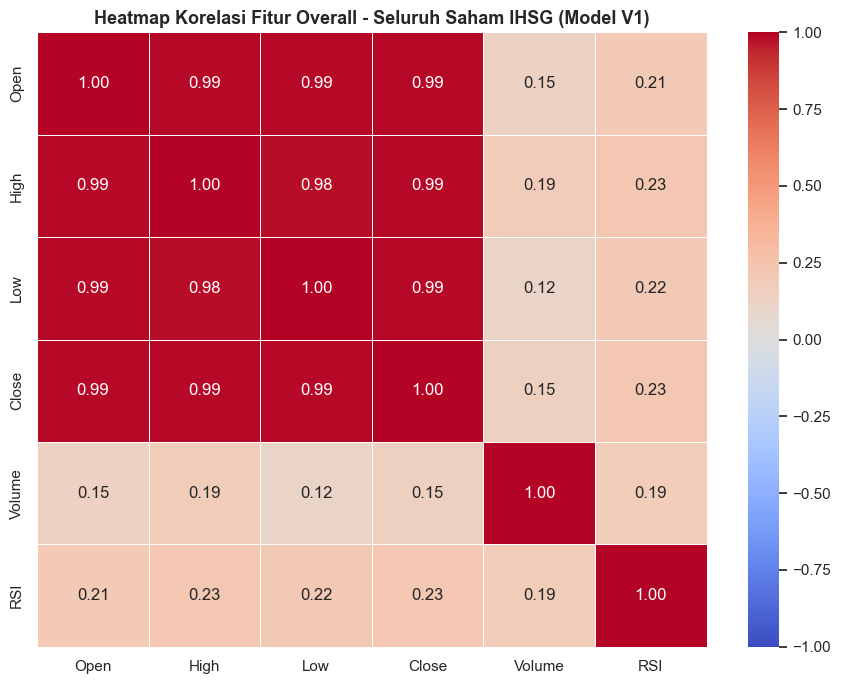

In [7]:
if os.path.exists(v1_path):
    # Buat salinan eod_data agar data mentah tidak berubah
    eod_corrected = v1_data.copy()
    num_days, num_stocks, num_features = eod_corrected.shape
    
    print("Mengkalkulasi ulang fitur RSI dan membuat matriks korelasi overall...")
    for s_idx in range(num_stocks):
        # Fitur indeks 3 adalah Close price (Z-Score normalized)
        close_prices = pd.Series(eod_corrected[:, s_idx, 3])
        
        # Rumus RSI dinamis
        delta = close_prices.diff()
        up = delta.clip(lower=0)
        down = -1 * delta.clip(upper=0)
        
        ema_up = up.ewm(com=13, adjust=False).mean()
        ema_down = down.ewm(com=13, adjust=False).mean()
        
        rs = ema_up / ema_down.replace(0, np.nan)
        rsi = 100 - (100 / (1 + rs))
        rsi_vals = rsi.fillna(50).replace([np.inf, -np.inf], [100, 0]).values
        
        # Normalisasi Z-Score untuk RSI agar seragam skalanya
        mean_rsi = np.nanmean(rsi_vals)
        std_rsi = np.nanstd(rsi_vals)
        if std_rsi != 0:
            rsi_vals = (rsi_vals - mean_rsi) / std_rsi
        else:
            rsi_vals = np.zeros_like(rsi_vals)
            
        # Masukkan ke kolom RSI (indeks ke-5)
        eod_corrected[:, s_idx, 5] = rsi_vals
        
    # Reshape dari 3D (Hari, Saham, Fitur) menjadi 2D (Hari * Saham, Fitur) untuk korelasi Overall
    overall_feat = eod_corrected.reshape(-1, num_features)
    df_overall = pd.DataFrame(overall_feat, columns=['Open', 'High', 'Low', 'Close', 'Volume', 'RSI'])
    
    # Hitung korelasi
    corr_matrix_overall = df_overall.corr()
    
    # Visualisasikan Heatmap Korelasi Overall
    plt.figure(figsize=(9, 7))
    sns.heatmap(corr_matrix_overall, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
    plt.title("Heatmap Korelasi Fitur Overall - Seluruh Saham IHSG (Model V1)", fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("Silakan buat dataset V1 terlebih dahulu.")

--- 
## 4. Visualisasi Runtun Waktu & Distribusi Target (V1)

Di bawah ini kita memplot tren harga penutupan (`Close`), volume transaksi, dan momentum `RSI` dalam runtun waktu (time series) pada satu saham contoh (seperti **BBCA.JK**), diikuti oleh grafik distribusi dari target return harian (Ground Truth).

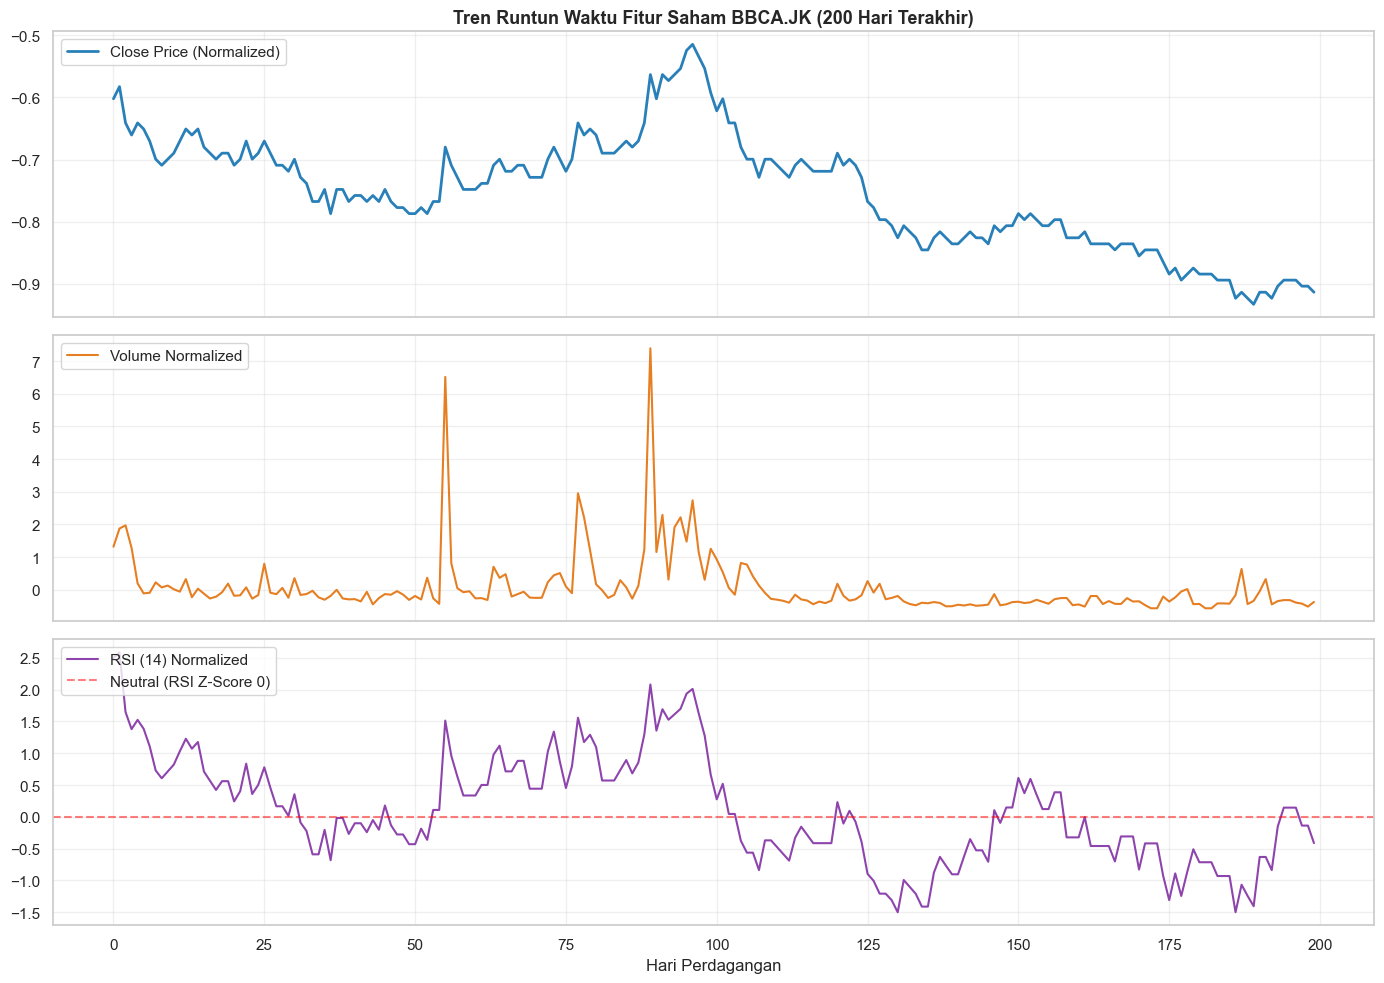

In [8]:
if os.path.exists(v1_path):
    # Ambil list ticker
    tickers = pd.read_csv('ihsg_all.csv')['Ticker'].dropna().unique().tolist()
    sample_ticker = 'BBCA.JK'
    
    if sample_ticker in tickers:
        ticker_idx = tickers.index(sample_ticker)
    else:
        ticker_idx = 0
        sample_ticker = tickers[0]
        
    # Ambil data runtun waktu saham terpilih dari matriks yang telah dikoreksi RSI-nya
    stock_feat = eod_corrected[:, ticker_idx, :]
    df_feat = pd.DataFrame(stock_feat, columns=['Open', 'High', 'Low', 'Close', 'Volume', 'RSI'])
    
    plot_len = min(200, df_feat.shape[0])
    df_plot = df_feat.tail(plot_len).copy().reset_index(drop=True)
    
    fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
    
    # 1. Plot Close Price
    axes[0].plot(df_plot['Close'], color='#2980b9', lw=2, label='Close Price (Normalized)')
    axes[0].set_title(f"Tren Runtun Waktu Fitur Saham {sample_ticker} (200 Hari Terakhir)", fontsize=13, fontweight='bold')
    axes[0].legend(loc='upper left')
    axes[0].grid(True, alpha=0.3)
    
    # 2. Plot Volume
    axes[1].plot(df_plot['Volume'], color='#e67e22', lw=1.5, label='Volume Normalized')
    axes[1].legend(loc='upper left')
    axes[1].grid(True, alpha=0.3)
    
    # 3. Plot RSI
    axes[2].plot(df_plot['RSI'], color='#8e44ad', lw=1.5, label='RSI (14) Normalized')
    axes[2].axhline(0, color='red', ls='--', alpha=0.5, label='Neutral (RSI Z-Score 0)')
    axes[2].legend(loc='upper left')
    axes[2].grid(True, alpha=0.3)
    axes[2].set_xlabel("Hari Perdagangan")
    
    plt.tight_layout()
    plt.show()
else:
    print("Silakan buat dataset V1 terlebih dahulu.")

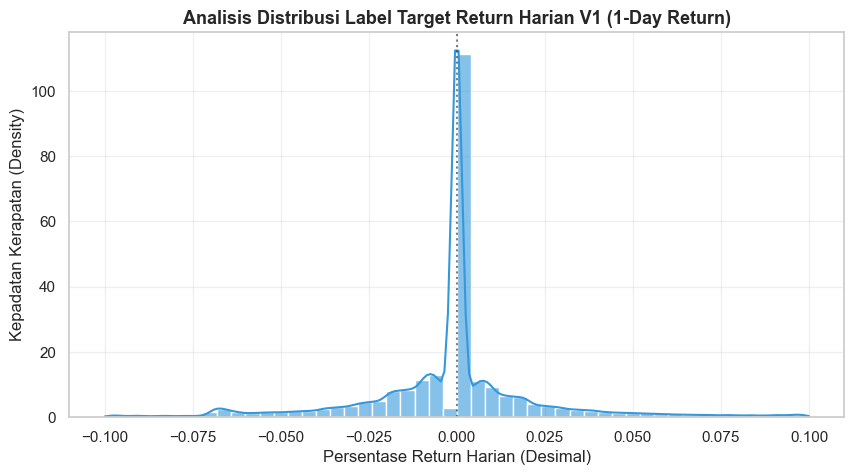

In [9]:
if os.path.exists(v1_path):
    v1_returns = v1_gt.flatten()
    
    # Filter data pencilan ekstrim untuk visualisasi kurva distribusi yang rapi
    v1_filt = v1_returns[(v1_returns > -0.1) & (v1_returns < 0.1)]
    
    plt.figure(figsize=(10, 5))
    sns.histplot(v1_filt, kde=True, color='#3498db', bins=50, stat="density", alpha=0.6)
    plt.axvline(0, color='black', linestyle=':', alpha=0.5)
    plt.title("Analisis Distribusi Label Target Return Harian V1 (1-Day Return)", fontsize=13, fontweight='bold')
    plt.xlabel("Persentase Return Harian (Desimal)")
    plt.ylabel("Kepadatan Kerapatan (Density)")
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("Dataset V1 belum siap.")

--- 
## 5. Hasil Model Machine Learning (Model Output)

Bagian ini memuat file hasil rekomendasi model V1 terbaru dari folder `outputs/` guna melihat hasil top rekomendasi beli (Bullish) di bursa IHSG.

In [10]:
output_root = 'outputs'
if os.path.exists(output_root):
    # Ambil folder tanggal terbaru
    dates = [d for d in os.listdir(output_root) if os.path.isdir(os.path.join(output_root, d)) and '-' in d]
    dates.sort(reverse=True)
    
    if dates:
        latest_date = dates[0]
        v1_csv = os.path.join(output_root, latest_date, 'rekomendasi_lengkap_IDX_ALL.csv')
        
        print(f"Membaca data output prediksi tanggal: {latest_date}\n")
        
        if os.path.exists(v1_csv):
            df_v1 = pd.read_csv(v1_csv)
            
            # Plot Top 10 V1
            plt.figure(figsize=(12, 6))
            top10_v1 = df_v1.head(10)
            sns.barplot(x='AI_Score', y='Ticker', data=top10_v1, palette='viridis', hue='Ticker', legend=False)
            plt.title(f"Model V1 (1-Day): Top 10 Bullish Saham IHSG ({latest_date})", fontsize=13, fontweight='bold')
            plt.xlabel("Conviction Score (Skor Keyakinan AI Model)")
            plt.ylabel("Ticker Saham")
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()
            
            print("\n--- TABEL TOP 10 REKOMENDASI SAHAM BULLISH MODEL V1 ---")
            print(df_v1[['Ticker', 'Harga', 'Trx_Miliar', 'AI_Score']].head(10).to_string(index=False))
        else:
            print(f"File output CSV '{v1_csv}' tidak ditemukan.")
    else:
        print("Belum ada data output prediksi di folder outputs.")
else:
    print("Folder outputs tidak ditemukan.")

Membaca data output prediksi tanggal: 2026-06-23

File output CSV 'outputs\2026-06-23\rekomendasi_lengkap_IDX_ALL.csv' tidak ditemukan.


--- 
## 6. Simpulan & Rekomendasi

Berikut adalah poin ringkas kesimpulan Model V1 untuk dipindahkan ke slide presentasi Anda:

1.  **Efisiensi Fitur V1**: Menggunakan 6 fitur dasar (`Open`, `High`, `Low`, `Close`, `Volume`, `RSI`) yang mampu melatih model deep learning secara cepat tanpa membebani memori.
2.  **Korelasi Fitur**: Fitur harga (`OHLC`) terbukti berkorelasi hampir sempurna (multikolinier), sementara fitur `Volume` dan `RSI` memberikan informasi tambahan independen tentang kekuatan tren dan aktivitas transaksi.
3.  **Target Horizon**: Model V1 fokus memprediksi fluktuasi harian (1 hari ke depan) sehingga sangat sesuai untuk kebutuhan perdagangan jangka pendek (*day trading*).
4.  **Mitigasi Risiko Likuiditas**: Penyaringan otomatis terhadap saham berharga kurang dari Rp 51 (menghindari saham gocap) dan transaksi harian di bawah Rp 1 Miliar berhasil menyaring saham yang tidak likuid, menjaga agar rekomendasi aman untuk dieksekusi secara riil.